-----------------------------DATASET VIVIENDAS CALIFORNIA-------------------------------------
# EDA de Viviendas en California

Análisis exploratorio del dataset con el objetivo de identificar qué variables parecen influir más en el precio de las viviendas.

Se analizarán distribuciones, correlaciones, patrones y posibles relaciones entre variables económicas, geográficas y estructurales.

Librerías para manipulación de datos, visualización y análisis exploratorio.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el archivo
df = pd.read_csv('housing.csv')

_Inspección del dataset._

Inspección inicial del dataset para comprender su estructura y observar las primeras filas.

In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


---
Exploración inicial

In [9]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Se detecto un total de 10 columnas (se corrobora el nombre de las mismas), todas tipo float y ocean_proximity de texto.

HIPOTESIS.
Posible presencia de outliers en median_house_value por la diferencia entre la media y mediana sobre nuestro enfoque.

---
Limpieza de Datos

In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)

Se utilizó la mediana para reemplazar valores faltantes debido a que es menos sensible a valores extremos.

PAIRPLOT PARA ANÁLISIS RÁPIDO

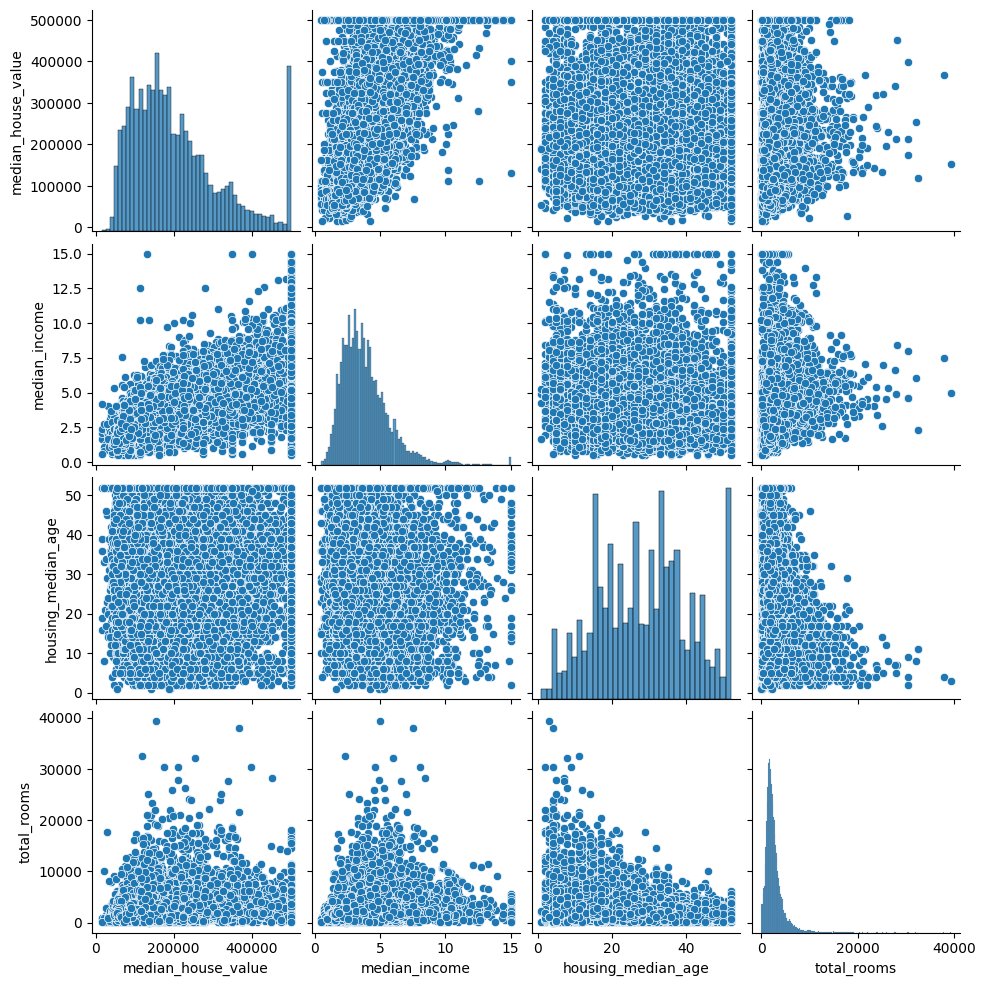

In [57]:
sns.pairplot(
    df[
        [
            "median_house_value",
            "median_income",
            "housing_median_age",
            "total_rooms"
        ]
    ]
)

plt.show()

Se utilizó un pairplot para visualizar simultáneamente distribuciones y relaciones entre variables importantes del dataset.

---
Análisis de una variable

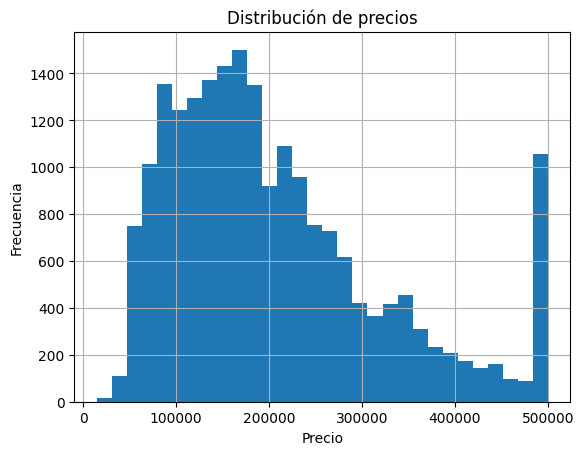

In [58]:
df["median_house_value"].hist(bins=30)

plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

La distribución presenta una cola hacia la derecha, indicando la presencia de viviendas con precios considerablemente mayores al resto.

---
Relación entre dos variables

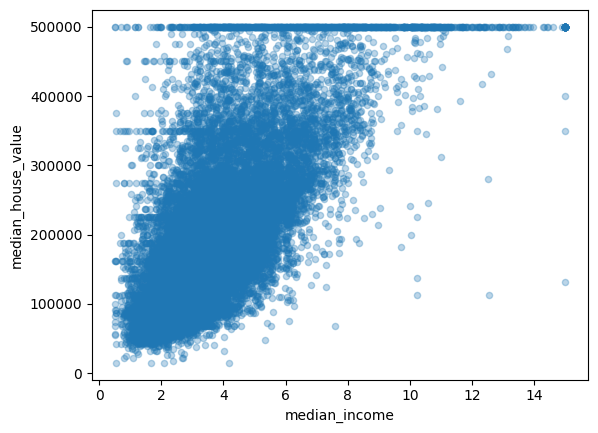

In [51]:
df.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.3
)

plt.show()

Se observa una relación positiva entre el ingreso medio y el valor de las viviendas.

---
Correlación

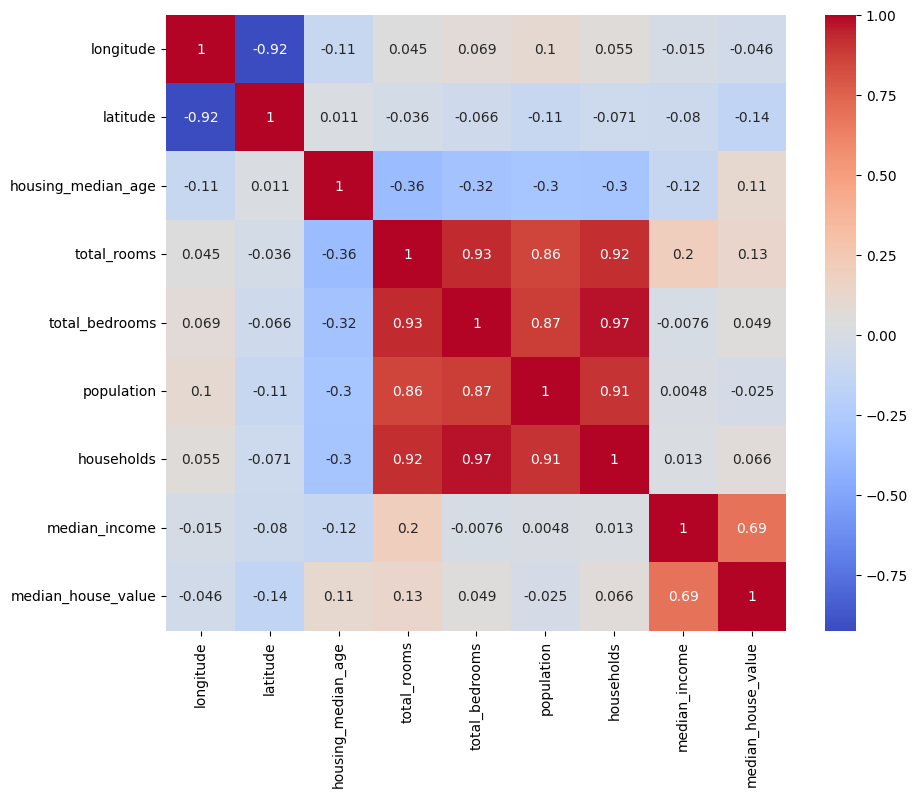

In [52]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

El ingreso medio mostró una de las correlaciones positivas más fuertes respecto al precio de las viviendas.

HIPOSTESIS.
Categorías de proximidad al oceano pueden afectar los precios de las casas.

---
Análisis por categorías

HEATMAP DE CATEGORÍAS

<Axes: >

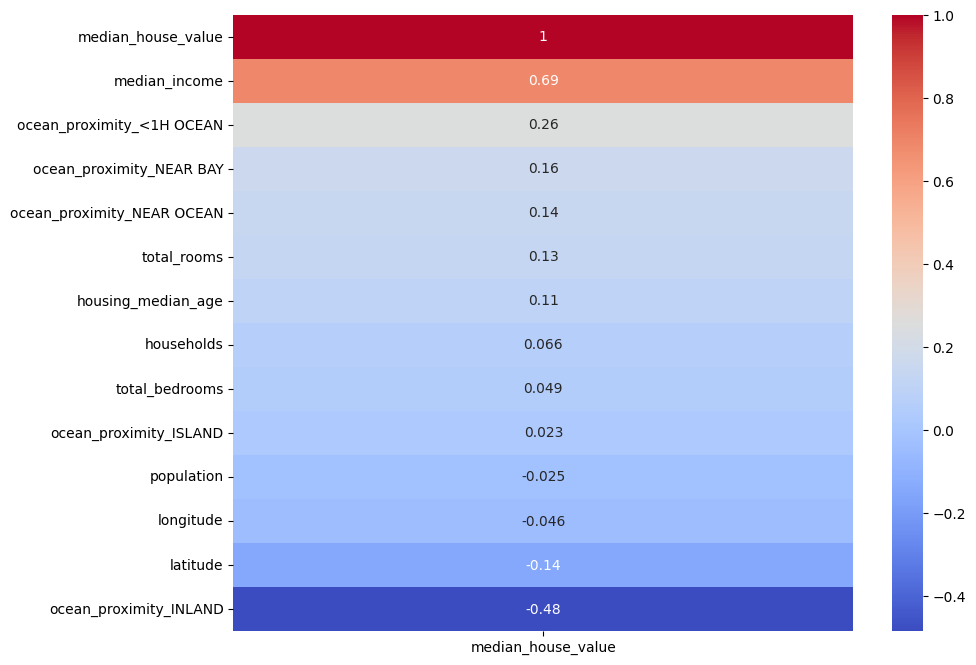

In [53]:
# Creamos variables numéricas para cada categoría de proximidad
df_con_dummies = pd.get_dummies(df, columns=['ocean_proximity'])

# Ahora calculamos la correlación sobre este nuevo DataFrame
corr_matrix = df_con_dummies.corr()
plt.figure(figsize=(10,8))

# Generamos el heatmap (enfocándonos en la relación con el precio)
sns.heatmap(
            corr_matrix[['median_house_value']].sort_values(by='median_house_value', ascending=False), 
            annot=True, 
            cmap='coolwarm'
)

Se observa una correlación positiva fuerte con las categorías de proximidad al océano con respecto a los precios de las casas.

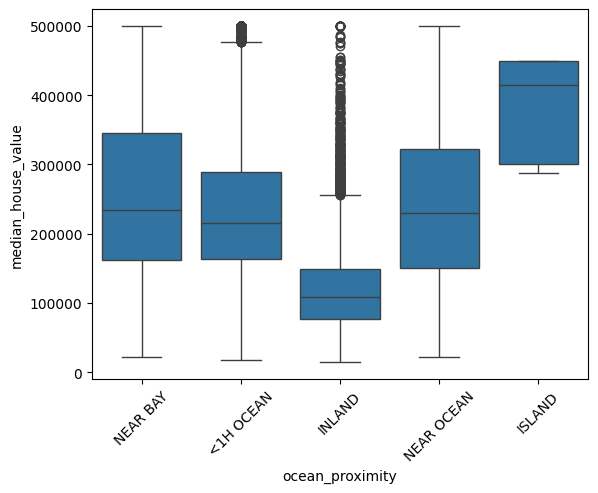

In [54]:
sns.boxplot(
    x="ocean_proximity",
    y="median_house_value",
    data=df
)

plt.xticks(rotation=45)

plt.show()

Las viviendas cercanas al océano presentan precios medianos considerablemente más altos que las viviendas tierra adentro.

---


HALLAZGOS

- El ingreso medio mostró una fuerte relación positiva con el precio de las viviendas.
- Las zonas cercanas al océano presentan propiedades considerablemente más costosas.
- Se detectaron valores extremos que afectan métricas como el promedio.

---
CONCLUSIÓN.

El análisis exploratorio permitió identificar relaciones importantes entre variables económicas y geográficas con el precio de las viviendas.

Factores como el ingreso medio y la cercanía al océano parecen influir significativamente en el valor de las propiedades.